#Dataset

In [2]:
import pandas as pd
df=pd.read_csv('/content/clean_nutrition_dataset.csv')

In [3]:
df.head()

,fdc_id,food_name,carbs,calories,fiber,iron,magnesium,protein,sodium,fat,category
0,1105904,WESSON Vegetable Oil 1 GAL,0.00,867.0,0.0,0.00,0.0,0.00,0.0,93.33,Others
1,1105905,SWANSON BROTH BEEF,0.42,4.0,0.0,0.00,0.0,0.83,346.0,0.00,Others
2,1105906,CAMPBELL'S SLOW KETTLE SOUP CLAM CHOWDER,6.12,82.0,0.4,0.24,0.0,2.45,363.0,5.31,Others
3,1105907,CAMPBELL'S SLOW KETTLE SOUP CHEESE BROCCOLI,5.31,82.0,0.4,0.16,0.0,1.22,322.0,6.12,Others
4,1105908,SWANSON BROTH CHICKEN,0.42,4.0,0.0,0.00,0.0,0.83,15.0,0.00,Others


print first 5 raws to see data

#Data Preprocessing

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913614 entries, 0 to 1913613
Data columns (total 11 columns):
 #   Column     Dtype  
---  ------     -----  
 0   fdc_id     int64  
 1   food_name  object 
 2   carbs      float64
 3   calories   float64
 4   fiber      float64
 5   iron       float64
 6   magnesium  float64
 7   protein    float64
 8   sodium     float64
 9   fat        float64
 10  category   object 
dtypes: float64(8), int64(1), object(2)
memory usage: 160.6+ MB


detetmine number of columns and datatypes and null values number of missing values in each column number of columns is 11 columns

In [5]:
df.shape

(1913614, 11)

determine number of raws and columns of dataset raws is 1913614 record and 11 column

In [6]:
df.describe()

,fdc_id,carbs,calories,fiber,iron,magnesium,protein,sodium,fat
count,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06,1.913614e+06
mean,1.604080e+06,3.373947e+01,2.686516e+02,2.432781e+00,3.893856e+00,7.615408e+00,7.533334e+00,1.481318e+03,1.226813e+01
std,7.054536e+05,4.882217e+01,3.567511e+02,7.058021e+00,6.860759e+02,1.061159e+03,1.421699e+01,9.639413e+04,2.211529e+01
min,1.675120e+05,-7.050000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.090500e+06,6.560000e+00,8.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,5.000000e-02,3.300000e+01,0.000000e+00
50%,1.665186e+06,2.231000e+01,2.590000e+02,8.000000e-01,5.600000e-01,0.000000e+00,4.580000e+00,2.540000e+02,5.130000e+00
75%,2.176232e+06,5.957000e+01,4.000000e+02,3.300000e+00,1.980000e+00,0.000000e+00,1.053000e+01,5.650000e+02,1.905000e+01
max,2.751503e+06,1.270000e+04,1.515150e+05,2.468900e+03,7.692308e+05,5.857140e+05,4.444440e+03,4.000000e+07,3.666670e+03


show statistics of data and compare mean and median to see if there is an outliers or not

#Data Cleaning

In [36]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
1913609,False
1913610,False
1913611,False
1913612,False


In [37]:
# Remove rows where target (calories) is missing
df = df.dropna(subset=["calories"])

In [38]:
df = df.reset_index(drop=True)

#handle Outliers

In [40]:
numerical_cols = df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)     # First quartile
    Q3 = df[col].quantile(0.75)     # Third quartile
    IQR = Q3 - Q1                   # Interquartile range

    lower = Q1 - 1.5 * IQR          # Lower bound
    upper = Q3 + 1.5 * IQR          # Upper bound

    df = df[(df[col] >= lower) & (df[col] <= upper)]

df.shape

(1170384, 11)

#EDA

A correlation matrix is used to measure the relationship between two features

Values close to 1 indicate a strong positive relationship (both increase together)

Values close to -1 indicate a strong negative relationship (one increases while the other decreases)

Values close to 0 mean there is little or no relationship

Text(0.5, 1.0, 'Correlation Heatmap')

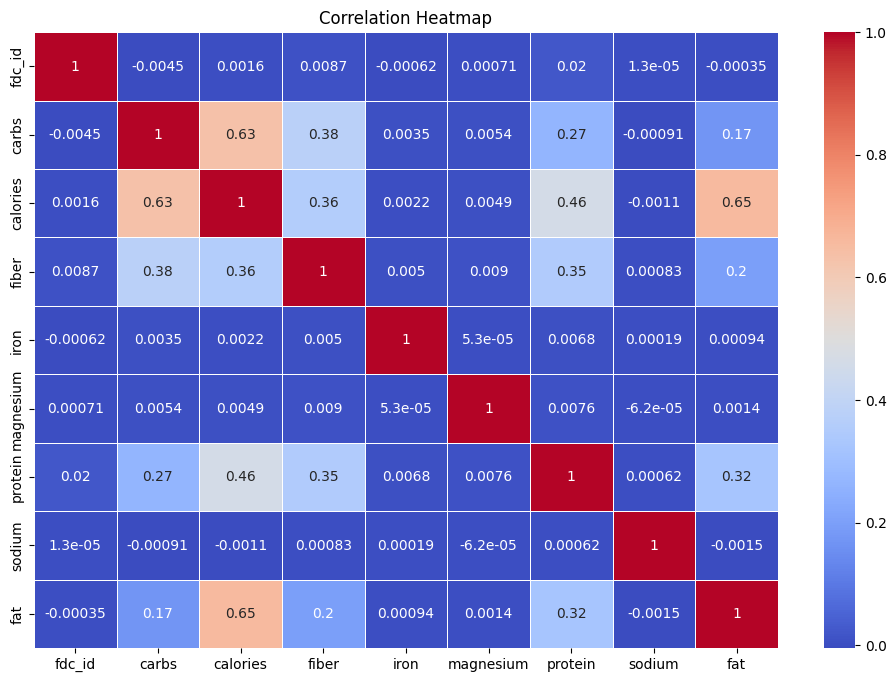

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
heatmap_data = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', linewidths=0.5,)
plt.title('Correlation Heatmap')



#From the heatmap:

The strongest relationship is between calories and fat (0.65)

The second strongest is between calories and carbs (0.63)

This shows that foods higher in fat or carbs usually contain more calories

Nutrients like iron, magnesium, and sodium have very weak relationships with other features

<Figure size 2000x1000 with 0 Axes>

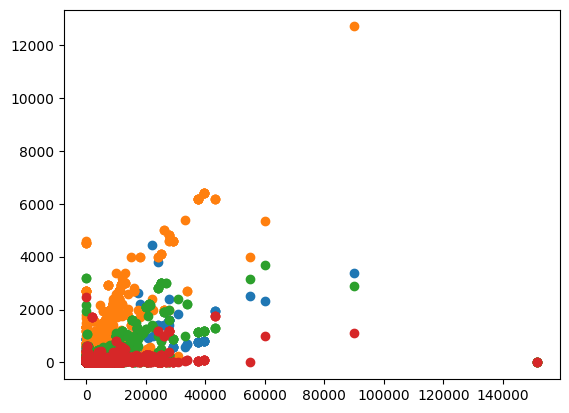

<Figure size 2000x1000 with 0 Axes>

In [10]:
figure1=plt.scatter(x='calories',y='protein',data=df)
figure2=plt.scatter(x='calories',y='carbs',data=df)
figure3=plt.scatter(x='calories',y='fat',data=df)
figure4=plt.scatter(x='calories',y='fiber',data=df)
plt.figure(figsize=(20,10))


<Figure size 2000x1000 with 0 Axes>

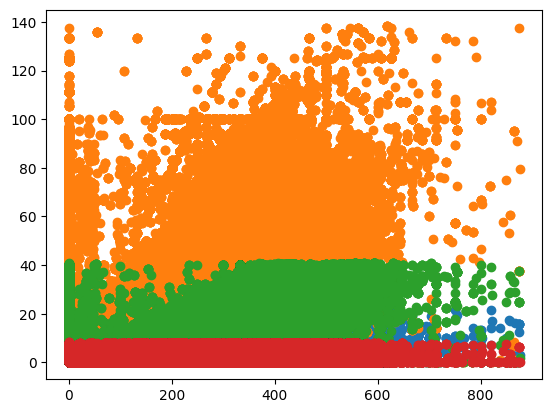

<Figure size 2000x1000 with 0 Axes>

In [11]:
figure1=plt.scatter(x='calories',y='protein',data=df_clean)
figure2=plt.scatter(x='calories',y='carbs',data=df_clean)
figure3=plt.scatter(x='calories',y='fat',data=df_clean)
figure4=plt.scatter(x='calories',y='fiber',data=df_clean)
plt.figure(figsize=(20,10))


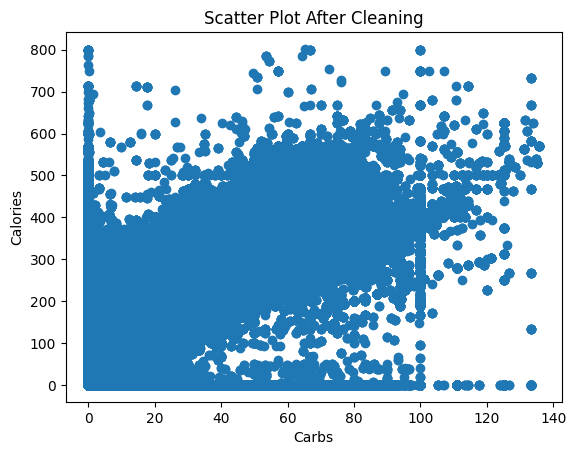

In [41]:
import matplotlib.pyplot as plt

plt.scatter(df['carbs'], df['calories'])
plt.xlabel("Carbs")
plt.ylabel("Calories")
plt.title("Scatter Plot After Cleaning")
plt.show()


#Scaling

In [13]:
from sklearn.preprocessing import StandardScaler

features = ['carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium']
target = ['calories']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X = scaler_X.fit_transform(df_clean[features])
y = scaler_y.fit_transform(df_clean[target])

#Feature Engineering

In [16]:
import numpy as np

# Guard against zeros before ratios
df_clean['macro_sum'] = (df_clean['carbs'] + df_clean['protein'] + df_clean['fat']).replace(0, np.nan)
df_clean['calories'] = df_clean['calories'].replace(0, np.nan)

# Engineered features
df_clean['calorie_density'] = df_clean['calories'] / 100
df_clean['carb_ratio'] = df_clean['carbs'] / df_clean['macro_sum']
df_clean['protein_ratio'] = df_clean['protein'] / df_clean['macro_sum']
df_clean['fat_ratio'] = df_clean['fat'] / df_clean['macro_sum']
df_clean['nutrient_density'] = df_clean['macro_sum'] / df_clean['calories']

# Final feature list used downstream
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
 ]

# Clean up infinities and drop rows missing engineered features
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=final_features + ['calories'])

In [17]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

In [18]:
X = scaler_X.fit_transform(df_clean[final_features])
y = scaler_y.fit_transform(df_clean[['calories']])

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[final_features])

#Modeling

In [20]:
from sklearn.cluster import KMeans

k = 6
kmeans = KMeans(n_clusters=k, random_state=42)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

In [21]:
import numpy as np

embeddings = X_scaled  # already scaled
df_clean['embedding'] = list(embeddings)

In [23]:
!pip install rapidfuzz
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz import process, fuzz
import numpy as np

def find_closest_food(query):
    choices = df_clean['food_name'].values
    match, score, idx = process.extractOne(query, choices, scorer=fuzz.WRatio)
    return match

def recommend(query, top_n=5):

    # 1. Find closest matching food name
    food_name = find_closest_food(query)

    # 2. Get index
    idx = df_clean.index[df_clean['food_name'] == food_name][0]

    # 3. Vector
    food_vec = df_clean.loc[idx, 'embedding'].reshape(1, -1)

    # 4. Similarity
    sims = cosine_similarity(food_vec, np.vstack(df_clean['embedding'])).flatten()

    # 5. Sort
    df_clean['similarity'] = sims
    results = (
        df_clean.sort_values(by='similarity', ascending=False)
        [['food_name', 'category', 'similarity', 'cluster']]
        .head(top_n+1)[1:]
    )

    print(f"Input: {query}\nMatched: {food_name}")
    return results

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 70.5 MB/s eta 0:00:00


In [24]:
recommend("oats")

Input: oats
Matched: OEP Mini Flour Tort Boats 12Ct


,food_name,category,similarity,cluster
553569,OEP Sft Mini Flr TrtllBwl 20Ct,Others,1.0,4
553597,OEP Mini Flour Tort Boats 12Ct,Others,1.0,4
788436,OEP Mini Flour Tort Boats 12Ct,Others,1.0,4
372772,Old El Paso Soft Flour Tortilla Taco Bowls,Others,1.0,4
788352,OEP Sft Mini Flr TrtllBwl 20Ct,Others,1.0,4


#Model XGBoost

In [25]:
final_features = [
    'carbs', 'fat', 'protein', 'fiber', 'iron', 'magnesium', 'sodium',
    'calorie_density',
    'carb_ratio', 'protein_ratio', 'fat_ratio',
    'nutrient_density'
]

X = df_clean[final_features]
y = df_clean['calories']

#Normalized

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

In [27]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train.ravel())

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [28]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
pred_scaled = xgb.predict(X_test).reshape(-1,1)
pred = scaler_y.inverse_transform(pred_scaled)
y_real = scaler_y.inverse_transform(y_test)

rmse = np.sqrt(mean_squared_error(y_real, pred))
mae = mean_absolute_error(y_real, pred)

print("XGBoost RMSE:", rmse)
print("XGBoost MAE :", mae)

XGBoost RMSE: 1.4156956955078939
XGBoost MAE : 0.8698827564294208


In [29]:
def predict_calories_xgb(sample_dict):

    # Convert dictionary → DataFrame
    df_inp = pd.DataFrame([sample_dict])[final_features]

    # Scale input
    scaled = scaler_X.transform(df_inp)

    # Predict (scaled calories)
    pred_scaled = xgb.predict(scaled).reshape(-1,1)

    # Convert back to real calories
    predicted = scaler_y.inverse_transform(pred_scaled)

    return predicted[0][0]  # return number only


# Example sample input
sample = {
    'carbs': 30,
    'fat': 5,
    'protein': 12,
    'fiber': 4,
    'iron': 2,
    'magnesium': 20,
    'sodium': 180,
    'calorie_density': 1.3,
    'carb_ratio': 0.55,
    'protein_ratio': 0.25,
    'fat_ratio': 0.20,
    'nutrient_density': 0.03
}

cal = predict_calories_xgb(sample)
print("Predicted Calories:", cal)

Predicted Calories: 143.87535
